In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

In [2]:
model = joblib.load("../saved_models/fraud_model.pkl")
print("Fraud model loaded successfully.")

Fraud model loaded successfully.


In [3]:
np.random.seed(42)

n_samples = 200

damage_classes = [
    "Front Breakage",
    "Front Crushed",
    "Rear Breakage",
    "Rear Crushed"
]

severity_levels = [
    "Moderate",
    "Severe",
    "Total Loss"
]

rows = []

for _ in range(n_samples):
    damage_class = np.random.choice(damage_classes)
    vehicle_age = np.random.randint(0, 15)
    mileage = np.random.randint(0, 200000)
    repair_cost = np.random.randint(20000, 150000)
    claim_amount = repair_cost * np.random.uniform(0.9, 1.4)
    claim_severity = np.random.choice(severity_levels)
    prior_claims = np.random.randint(0, 5)
    policy_age_months = np.random.randint(1, 120)
    days_since_policy_inception = np.random.randint(1, 3650)

    rows.append([
        damage_class,
        vehicle_age,
        mileage,
        repair_cost,
        claim_amount,
        claim_severity,
        prior_claims,
        policy_age_months,
        days_since_policy_inception
    ])

X_sample = pd.DataFrame(
    rows,
    columns=[
        "damage_class",
        "vehicle_age",
        "mileage",
        "repair_cost",
        "claim_amount",
        "claim_severity",
        "prior_claims",
        "policy_age_months",
        "days_since_policy_inception"
    ]
)

X_sample.head()

,damage_class,vehicle_age,mileage,repair_cost,claim_amount,claim_severity,prior_claims,policy_age_months,days_since_policy_inception
0,Rear Breakage,3,131932,123694,156596.229319,Moderate,4,103,2170
1,Rear Breakage,6,168266,107498,143304.301659,Total Loss,4,2,2392
2,Rear Crushed,13,199041,25311,35336.833389,Moderate,3,58,22
3,Front Breakage,11,130608,126970,153116.481021,Severe,3,60,976
4,Rear Breakage,13,129981,104654,126546.884710,Total Loss,3,64,1529


In [4]:
fraud_probabilities = model.predict_proba(X_sample)[:, 1]

print("Average Fraud Probability:", fraud_probabilities.mean())

Average Fraud Probability: 0.3114253


In [5]:
preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["classifier"]

In [6]:
X_transformed = preprocessor.transform(X_sample)

feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))

Number of transformed features: 14


In [9]:
explainer = shap.Explainer(
    classifier.predict_proba,
    X_transformed
)

# Compute SHAP values
shap_values = explainer(X_transformed)

PermutationExplainer explainer: 201it [01:49,  1.83it/s]                                                               


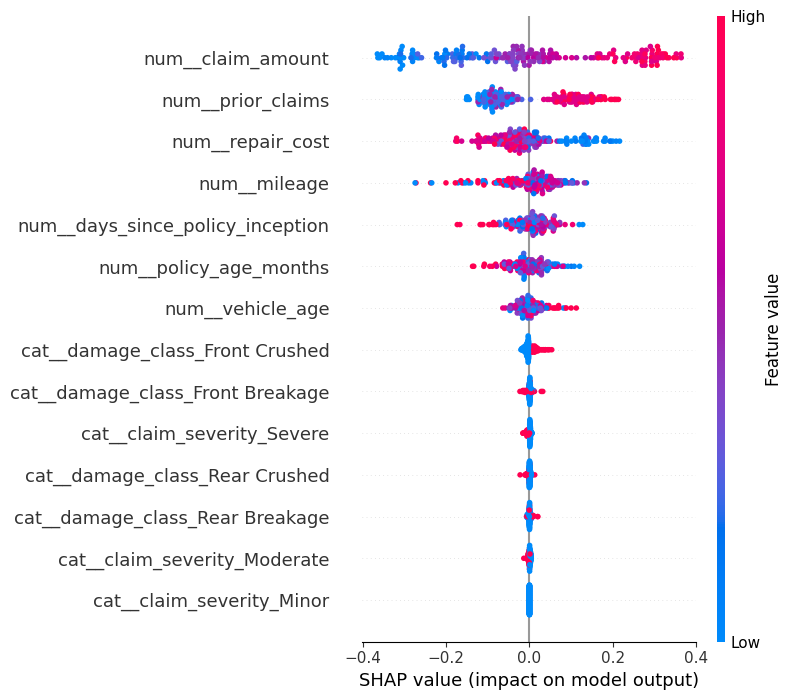

In [10]:
shap.summary_plot(
    shap_values.values[:, :, 1],
    X_transformed,
    feature_names=feature_names
)

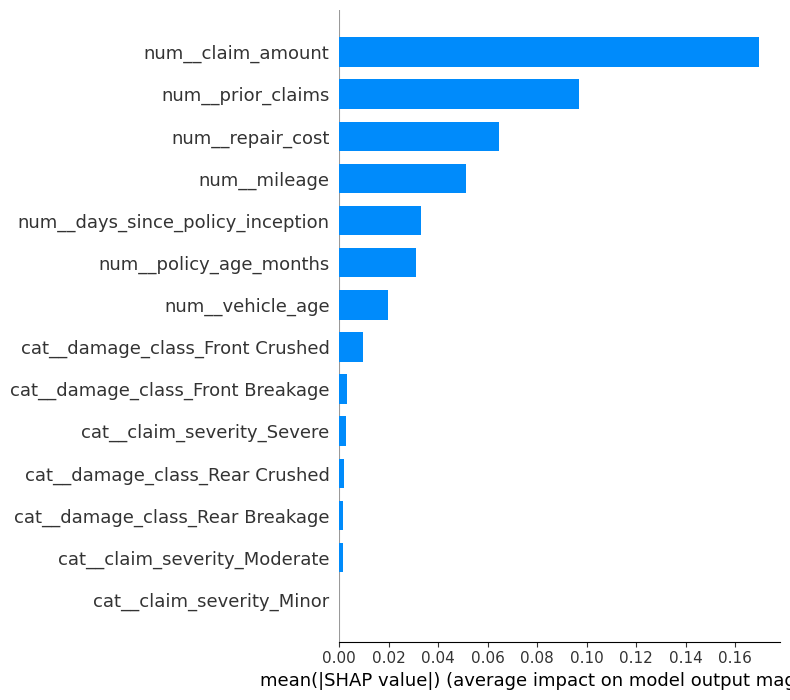

In [11]:
shap.summary_plot(
    shap_values.values[:, :, 1],
    X_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

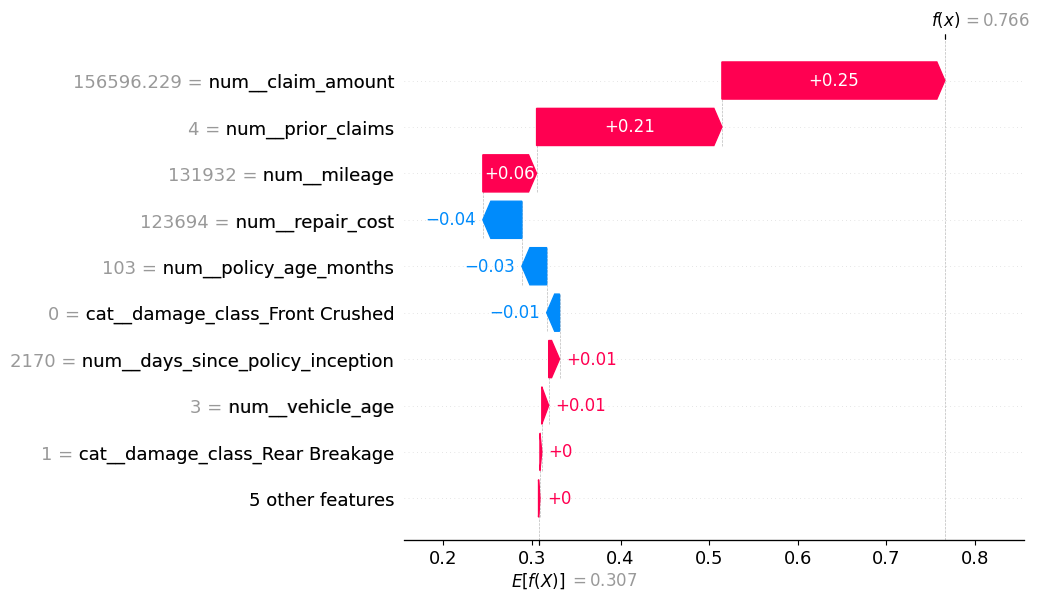

In [12]:
index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values.values[index, :, 1],
        base_values=shap_values.base_values[index, 1],
        data=X_transformed[index],
        feature_names=feature_names
    )
)

In [13]:
index = 0

contributions = pd.DataFrame({
    "feature": feature_names,
    "shap_value": shap_values.values[index, :, 1]
})

contributions["abs_shap"] = contributions["shap_value"].abs()

top_drivers = (
    contributions
    .sort_values("abs_shap", ascending=False)
    .head(10)
)

top_drivers[["feature", "shap_value"]]

,feature,shap_value
10,num__claim_amount,0.251744
11,num__prior_claims,0.209249
8,num__mileage,0.060670
9,num__repair_cost,-0.044098
12,num__policy_age_months,-0.027977
1,cat__damage_class_Front Crushed,-0.014537
13,num__days_since_policy_inception,0.012271
7,num__vehicle_age,0.007773
2,cat__damage_class_Rear Breakage,0.002095
3,cat__damage_class_Rear Crushed,0.001854


SHAP summary plot saved successfully.


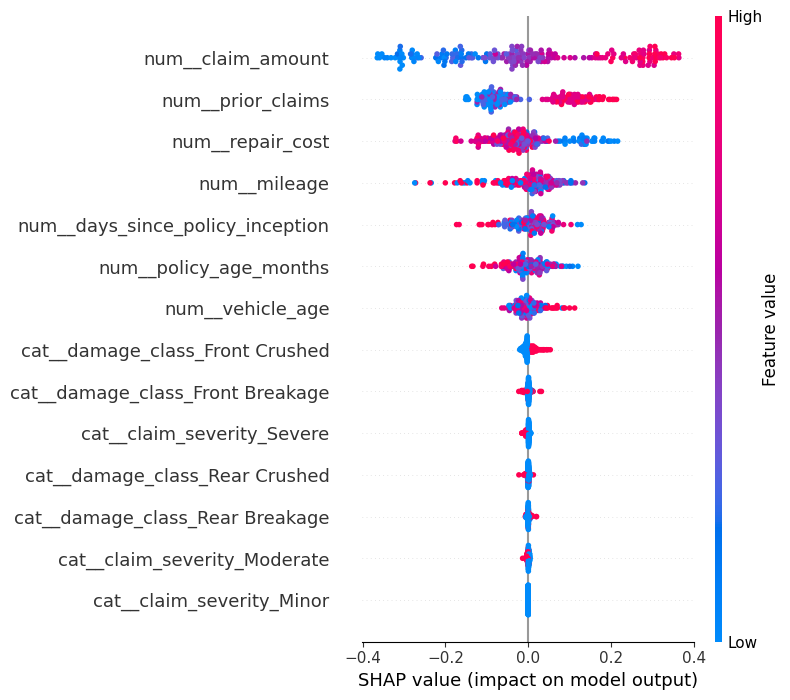

In [14]:
os.makedirs("../reports", exist_ok=True)

plt.figure()
shap.summary_plot(
    shap_values.values[:, :, 1],
    X_transformed,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.savefig(
    "../reports/fraud_shap_summary.png",
    bbox_inches="tight"
)

print("SHAP summary plot saved successfully.")

In [15]:
for _, row in top_drivers.iterrows():
    direction = "increased" if row["shap_value"] > 0 else "decreased"
    print(
        f"{row['feature']} {direction} fraud risk "
        f"by {abs(row['shap_value']):.4f}"
    )

num__claim_amount increased fraud risk by 0.2517
num__prior_claims increased fraud risk by 0.2092
num__mileage increased fraud risk by 0.0607
num__repair_cost decreased fraud risk by 0.0441
num__policy_age_months decreased fraud risk by 0.0280
cat__damage_class_Front Crushed decreased fraud risk by 0.0145
num__days_since_policy_inception increased fraud risk by 0.0123
num__vehicle_age increased fraud risk by 0.0078
cat__damage_class_Rear Breakage increased fraud risk by 0.0021
cat__damage_class_Rear Crushed increased fraud risk by 0.0019
